<a href="https://colab.research.google.com/github/vivektirumalasetty/Object-Detector/blob/main/ObjectDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import cv2
import torch
import torchvision.transforms as transforms

In [ ]:
device = torch.device('cuda')
#the model expects gpu for processing

#data preprocessing
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
model = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_ssd')
model.load_state_dict(torch.load('/root/.cache/torch/hub/checkpoints/ssd300_mAP_77.43_v2.pth', map_location=device))
model.to(device)
model.eval()

utils = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_ssd_processing_utils')

The repository NVIDIA_DeepLearningExamples does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/NVIDIA/DeepLearningExamples/zipball/torchhub" to /root/.cache/torch/hub/torchhub.zip


/root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/torch/hub/checkpoints/ssd300_mAP_77.43_v2.pth'

In [ ]:
img_path = '/content/drive/MyDrive/images/demo.avif'
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
tensor = transform(img)
tensor = tensor.unsqueeze(0).to(device)

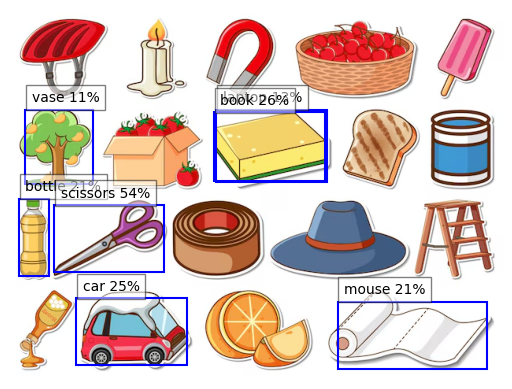

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

with torch.no_grad():
  output = model(tensor)

results_per_im = utils.decode_results(output)
best_results = [utils.pick_best(results, 0.45) for results in results_per_im]
classes_to_labels = utils.get_coco_object_dictionary()

for image_idx in range(len(best_results)):
    fig, ax = plt.subplots(1)

    image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(image)

    H, W, _ = image.shape

    bboxes, classes, confidences = best_results[image_idx]
    for idx in range(len(bboxes)):
        x1 , y1 , x2 , y2  = bboxes[idx]
        x = int(x1*W)
        y = int(y1*H)
        w = int((x2-x1)*W)
        h = int((y2-y1)*H)

        rect = patches.Rectangle((x, y),w, h, linewidth=1.5, edgecolor='b', facecolor='none')
        ax.add_patch(rect)

        ax.text(x+8, y-10, f"{classes_to_labels[classes[idx] - 1]} {int(confidences[idx]*100)}%", bbox= dict(facecolor='white', alpha=0.5))


plt.axis('off')
plt.show()

In [ ]:
def draw_bbox(image,results,classes):
  #starting a loop to iterate through every picture in a batch
  for img_idx in range(len(results)):
    img_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    H,W,_ = img_rgb.shape

    coords , labels , confidence = results[img_idx]

    #this loop is to draw boxes around every object detected in the picture
    for coord_idx in range(len(coords)):
      x1,x2,y1,y2 = coords[coord_idx]

      x1 = int(x1*W)
      y1 = int(y1*H)
      x2 = int(x2*W)
      y2 = int(y2*W)

      cv2.rectangle(image,(x1,y1),(x2,y2),(0,100,100),5)
      cv2.putText(image,classes[labels[idx-1]],(x1,y1-10),cv2.FONT_HERSHEY_SIMPLEX,2,(0,200,0),5)

  return image